# Klasyfikacja danych kredytowych

## Przygotowanie danych. 

Przed przystąpieniem do ćwiczeń pobierz plik `credit.csv` z MSTeams.

```python
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from imblearn.under_sampling import RandomUnderSampler

credit_df = pd.read_csv("credit.csv")
print(f"Dataset loaded: {credit_df.shape[0]} rows, {credit_df.shape[1]} columns")

X_raw = credit_df.drop(columns=['Class'])
y = credit_df['Class']

seed = 42
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=seed
)

# Sprawdź rozkład klas
print("\nRozkład klas:")
print(f"Train: {np.bincount(y_train)} (0={np.bincount(y_train)[0]}, 1={np.bincount(y_train)[1]})")
print(f"Test : {np.bincount(y_test)} (0={np.bincount(y_test)[0]}, 1={np.bincount(y_test)[1]})")
```

Zwróć uwagę na parametr ` stratify=y` w podziale danych.
Skalowanie cech `Time` i `Amount` metodą RobustScaler.

> Zadanie. Znajdź i wyjaśnij co robi metoda `RobustScaler`

```python
time_scaler = RobustScaler().fit(X_train[['Time']])
amount_scaler = RobustScaler().fit(X_train[['Amount']])

for dataset, name in zip([X_train, X_test], ['Train', 'Test']):
    dataset['scaled_time'] = time_scaler.transform(dataset[['Time']])
    dataset['scaled_amount'] = amount_scaler.transform(dataset[['Amount']])
    dataset.drop(['Time', 'Amount'], axis=1, inplace=True)
    print(f"{name} set scaled. Shape: {dataset.shape}")

X_train_scaled = X_train
X_test_scaled = X_test
```
### zbalansowanie danych metodą undersampling

```python
undersampler = RandomUnderSampler(random_state=seed)

# UWAGA: undersampling stosujemy tylko do zbioru treningowego
X_train_under, y_train_under = undersampler.fit_resample(X_train_scaled, y_train)
X_test_under, y_test_under = undersampler.fit_resample(X_test_scaled, y_test)
print(f"\nUndersampling completed:")
print(f"Train set balanced to: {np.bincount(y_train_under)} (0 and 1 equally frequent)")

print(f"Test set balanced to: {np.bincount(y_test_under)} (0 and 1 equally frequent)")

Undersampling completed:
Train set balanced to: [394 394] (0 and 1 equally frequent)
Test set balanced to: [98 98] (0 and 1 equally frequent)
```
```python
print("\nFinal shapes:")
print(f"X_train_under: {X_train_under.shape}")
print(f"y_train_under: {y_train_under.shape}")
print(f"X_test_scaled: {X_test_under.shape}")
print(f"y_test:        {y_test_under.shape}")

Final shapes:
X_train_under: (788, 30)
y_train_under: (788,)
X_test_scaled: (196, 30)
y_test:        (196,)


import os

# === 6. Zapisanie przygotowanych zbiorów do plików CSV ===

SAVE_DIR = "../../dane/przetworzone"
os.makedirs(SAVE_DIR, exist_ok=True)

X_train.to_csv(os.path.join(SAVE_DIR, "X_train.csv"), index=False)
y_train.to_csv(os.path.join(SAVE_DIR, "y_train.csv"), index=False)

# # Zbiór treningowy po undersamplingu (do trenowania modeli)
X_train_under.to_csv(os.path.join(SAVE_DIR, "X_train_under.csv"), index=False)
y_train_under.to_csv(os.path.join(SAVE_DIR, "y_train_under.csv"), index=False)

# # Zbiór testowy (pozostaje niezbalansowany, do oceny modeli)
X_test_under.to_csv(os.path.join(SAVE_DIR, "X_test_under.csv"), index=False)
y_test_under.to_csv(os.path.join(SAVE_DIR, "y_test_under.csv"), index=False)
```

### Metody selekcji zmiennych


```python

import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import MinMaxScaler

results = []

for column in X_train.columns:
    # Dane tylko z jedną zmienną
    feature_train = X_train[[column]]
    feature_test = X_test[[column]]
    
    # Skalowanie do 0–1
    scaler = MinMaxScaler()
    feature_train_scaled = scaler.fit_transform(feature_train)
    feature_test_scaled = scaler.transform(feature_test)

    # Regresja logistyczna
    model = LogisticRegression()
    model.fit(feature_train_scaled, y_train)

    # Predykcja i GINI
    probs = model.predict_proba(feature_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, probs)
    gini = 2 * auc - 1

    results.append((column, gini))

results_sorted = sorted(results, key=lambda x: x[1], reverse=True)

# Wyświetlenie
print("Top zmienne wg statystyki GINI (logreg 1-cechowa):\n")
for name, g in results_sorted:
    print(f"{name:<20}  GINI = {g:.4f}")

# Najlepsza zmienna
best_variable = results_sorted[0][0]
print(f"\n✅ Najlepsza zmienna: {best_variable}  (do modelu kwantowego 1-kubitowego)")

Top zmienne wg statystyki GINI (logreg 1-cechowa):

V12                   GINI = 0.9094
V14                   GINI = 0.9086
V11                   GINI = 0.8802
V4                    GINI = 0.8485
V3                    GINI = 0.8248
V10                   GINI = 0.8183
V16                   GINI = 0.7020
V7                    GINI = 0.6975
V17                   GINI = 0.6738
V9                    GINI = 0.6626
V1                    GINI = 0.6323
V6                    GINI = 0.5821
V18                   GINI = 0.5472
V5                    GINI = 0.4606
scaled_time           GINI = 0.2589
V23                   GINI = 0.1208
scaled_amount         GINI = 0.1156
V24                   GINI = 0.1108
V22                   GINI = 0.0233
V13                   GINI = -0.0158
V15                   GINI = -0.0395
V25                   GINI = -0.0943
V26                   GINI = -0.0987
...
V21                   GINI = -0.4992
V2                    GINI = -0.7163
```

Model XGB
```python
import xgboost as xgb

model = xgb.XGBClassifier(max_depth=1,n_estimators=1)
model.fit(X_train, y_train)

booster = model.get_booster()
df = booster.trees_to_dataframe()

# Pierwszy wiersz to pierwszy podział w pierwszym drzewie
split_variable = df.loc[0, "Feature"]
split_value = df.loc[0, "Split"]

print(f"Model użył zmiennej: {split_variable}, wartość progowa: {split_value}")
Model użył zmiennej: V14, wartość progowa: -3.6156354
```



## Jedno-kubitowe Modele Kwantowe

In [3]:
# ======================================================
# 1️⃣ IMPORTY I USTAWIENIA
# ======================================================
import os
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import pennylane as qml
import pennylane.numpy as np
from pennylane.optimize import NesterovMomentumOptimizer

# Ścieżka do katalogu z przetworzonymi danymi
DATA_DIR = "../data/credit/"

# ======================================================
# 2️⃣ WCZYTANIE DANYCH
# ======================================================
X_train_under = pd.read_csv(os.path.join(DATA_DIR, "X_train_under.csv"))
y_train = pd.read_csv(os.path.join(DATA_DIR, "y_train_under.csv"))

X_test = pd.read_csv(os.path.join(DATA_DIR, "X_test_under.csv"))
y_test = pd.read_csv(os.path.join(DATA_DIR, "y_test_under.csv"))

print(f"Train shape: X={X_train_under.shape}, y={y_train.shape}")
print(f"Test shape:  X={X_test.shape}, y={y_test.shape}")

y_train = y_train * 2 - 1
y_test = y_test * 2 - 1

Train shape: X=(788, 30), y=(788, 1)
Test shape:  X=(196, 30), y=(196, 1)


Skalowanie MinMax 

In [4]:
# Inicjalizacja skalera
# Zakres dla kątów rotacji
angle_min, angle_max = 0.1, np.pi-0.1

scaler = MinMaxScaler(feature_range=(angle_min, angle_max))

# Dopasowanie do całego zbioru (train + test)
scaler.fit(pd.concat([X_train_under, X_test], axis=0))

# Transformacja
X_train_scaled = scaler.transform(X_train_under)
X_test_scaled = scaler.transform(X_test)

# Zamiana na DataFrame (z zachowaniem nazw kolumn)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_under.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)


print("✅ Dane zostały przeskalowane globalnie metodą Min–Max do zakresu [0, 1].")
print(f"Zakres (train): min={X_train_scaled.min().min():.3f}, max={X_train_scaled.max().max():.3f}")
print(f"Zakres (test):  min={X_test_scaled.min().min():.3f}, max={X_test_scaled.max().max():.3f}")

✅ Dane zostały przeskalowane globalnie metodą Min–Max do zakresu [0, 1].
Zakres (train): min=0.100, max=3.042
Zakres (test):  min=0.100, max=3.042


In [10]:
# Używamy jednego kubitu
dev = qml.device("default.qubit", wires=1)

# ======================================================
# 2️⃣ DEFINICJA SIECI KWANTOWEJ
# ======================================================
@qml.qnode(dev)
def quantum_net(weights, x):
    """
    Prosty jednokubitowy model bez reuploadingu danych.
    Składa się z:
      - enkodowania danych przez rotację RY(x)
      - parametrycznej rotacji R(θ, φ, ω)
      - pomiaru obserwabli PauliZ
    """
    qml.RX(x, wires=0)
    qml.Rot(*weights, wires=0)
    return qml.expval(qml.PauliZ(0))  # wartość oczekiwana σz ∈ [-1, 1]

# ======================================================
# 4️⃣ FUNKCJE POMOCNICZE
# ======================================================
import pennylane as qml
import pennylane.numpy as np
from pennylane.optimize import NesterovMomentumOptimizer, AdamOptimizer
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

def variational_classifier(weights, bias, x):
    return quantum_net(weights, x) + bias

def square_loss(labels, predictions):
    return np.mean((labels - np.array(predictions))**2)

def accuracy(labels, predictions):
    labels_np = np.array(labels)
    preds_np = np.sign(np.array(predictions))  # -1/1
    return np.mean(labels_np == preds_np)

def precision(labels, predictions):
    labels_np = np.array(labels)
    preds_np = np.sign(np.array(predictions))
    return precision_score(labels_np, preds_np, pos_label=1)

def recall(labels, predictions):
    labels_np = np.array(labels)
    preds_np = np.sign(np.array(predictions))
    return recall_score(labels_np, preds_np, pos_label=1)

def f1(labels, predictions):
    labels_np = np.array(labels)
    preds_np = np.sign(np.array(predictions))
    return f1_score(labels_np, preds_np, pos_label=1)

def confusion(labels, predictions):
    labels_np = np.array(labels)
    preds_np = np.sign(np.array(predictions))
    return confusion_matrix(labels_np, preds_np)

def cost(weights, bias, X, Y):
    preds = [variational_classifier(weights, bias, x) for x in X]
    return square_loss(Y, preds)

In [8]:
np.random.seed(0)
num_qubits = 1
num_layers = 1
#weights_init = 0.01 * np.random.randn(num_layers, num_qubits, 3, requires_grad=True)
bias_init = np.array(0.0, requires_grad=True)

weights_shape = (3,)
weights_init = np.random.random(weights_shape, requires_grad=True)

print("Weights:", weights_init)
print("Bias: ", bias_init)

Weights: [0.5488135  0.71518937 0.60276338]
Bias:  0.0


(<Figure size 500x200 with 1 Axes>, <Axes: >)

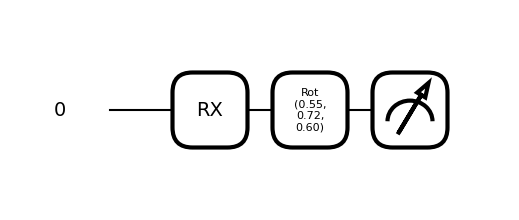

In [9]:
qml.draw_mpl(quantum_net, decimals=2, level='device')(weights_init, X_train_scaled[['V14']].values[0])

In [12]:
X_train_tens= np.array(X_train_scaled['V14'].values, requires_grad=False)
y_train_tens = np.array(y_train.values, requires_grad=False).flatten()

X_test_tens = np.array(X_test_scaled['V14'].values, requires_grad=False)
y_test_tens = np.array(y_test.values, requires_grad=False).flatten()

Epoch   0 | Train Loss: 0.818113 | Test Loss: 0.789380 | Acc: 0.645 | Prec: 1.000 | Recall: 0.289 | F1: 0.449
Epoch  10 | Train Loss: 0.557221 | Test Loss: 0.544902 | Acc: 0.921 | Prec: 0.991 | Recall: 0.850 | F1: 0.915
Epoch  20 | Train Loss: 0.521238 | Test Loss: 0.500753 | Acc: 0.868 | Prec: 1.000 | Recall: 0.736 | F1: 0.848
Epoch  30 | Train Loss: 0.499646 | Test Loss: 0.483484 | Acc: 0.905 | Prec: 0.997 | Recall: 0.812 | F1: 0.895
Epoch  40 | Train Loss: 0.483319 | Test Loss: 0.464092 | Acc: 0.896 | Prec: 1.000 | Recall: 0.792 | F1: 0.884
Epoch  50 | Train Loss: 0.467941 | Test Loss: 0.449137 | Acc: 0.902 | Prec: 1.000 | Recall: 0.805 | F1: 0.892
Epoch  60 | Train Loss: 0.459864 | Test Loss: 0.441867 | Acc: 0.904 | Prec: 1.000 | Recall: 0.807 | F1: 0.893
Epoch  70 | Train Loss: 0.458984 | Test Loss: 0.441163 | Acc: 0.904 | Prec: 0.997 | Recall: 0.810 | F1: 0.894
Epoch  80 | Train Loss: 0.459250 | Test Loss: 0.441394 | Acc: 0.904 | Prec: 0.997 | Recall: 0.810 | F1: 0.894
Epoch  90 

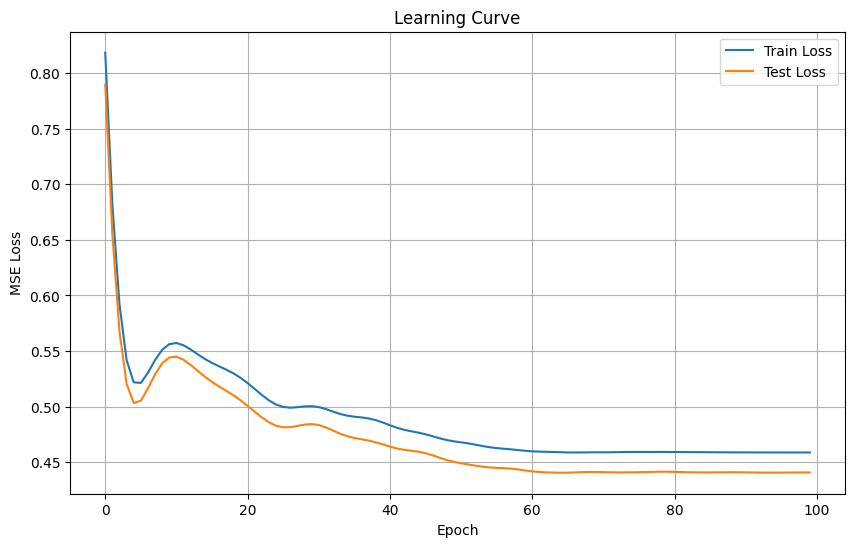

In [13]:
# =========================
# Pętla treningowa z historią metryk
# =========================
epochs = 100
weights = weights_init
bias = bias_init
opt = AdamOptimizer(stepsize=0.1)

train_loss_hist, test_loss_hist = [], []
train_acc_hist, test_acc_hist = [], []
train_prec_hist, test_prec_hist = [], []
train_rec_hist, test_rec_hist = [], []
train_f1_hist, test_f1_hist = [], []

for epoch in range(epochs):
    # krok optymalizacji
    weights, bias = opt.step(lambda w, b: cost(w, b, X_train_tens, y_train_tens), weights, bias)
    
    # --- obliczenie predykcji i metryk ---
    train_preds = [variational_classifier(weights, bias, x) for x in X_train_tens]
    test_preds = [variational_classifier(weights, bias, x) for x in X_test_tens]
    
    # straty
    train_loss = square_loss(y_train_tens, train_preds)
    test_loss = square_loss(y_test_tens, test_preds)
    
    # metryki
    train_acc = accuracy(y_train_tens, train_preds)
    test_acc = accuracy(y_test_tens, test_preds)
    train_prec = precision(y_train_tens, train_preds)
    test_prec = precision(y_test_tens, test_preds)
    train_rec = recall(y_train_tens, train_preds)
    test_rec = recall(y_test_tens, test_preds)
    train_f1 = f1(y_train_tens, train_preds)
    test_f1 = f1(y_test_tens, test_preds)
    
    # zapis historii
    train_loss_hist.append(train_loss)
    test_loss_hist.append(test_loss)
    train_acc_hist.append(train_acc)
    test_acc_hist.append(test_acc)
    train_prec_hist.append(train_prec)
    test_prec_hist.append(test_prec)
    train_rec_hist.append(train_rec)
    test_rec_hist.append(test_rec)
    train_f1_hist.append(train_f1)
    test_f1_hist.append(test_f1)
    
    # log
    if epoch % 10 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch:3d} | "
              f"Train Loss: {train_loss:.6f} | Test Loss: {test_loss:.6f} | "
              f"Acc: {train_acc:.3f} | Prec: {train_prec:.3f} | Recall: {train_rec:.3f} | F1: {train_f1:.3f}")

# =========================
# Wykres uczenia
# =========================
plt.figure(figsize=(10,6))
plt.plot(train_loss_hist, label='Train Loss')
plt.plot(test_loss_hist, label='Test Loss')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Learning Curve")
plt.legend()
plt.grid(True)
plt.show()

### test na duzym zbiorze

In [14]:
X_test_full = pd.read_csv(os.path.join(DATA_DIR, "X_test.csv"))
y_test_full = pd.read_csv(os.path.join(DATA_DIR, "y_test.csv"))
y_test_full = y_test_full * 2 - 1

In [15]:
X_test.shape, X_test_full.shape, y_test.shape, y_test_full.shape

((196, 30), (56962, 30), (196, 1), (56962, 1))

In [16]:
y_test_full_tens = np.array(y_test_full.values, requires_grad=False).flatten()

In [17]:
X_test_full_scaled = scaler.transform(X_test_full)
X_test_full_scaled = pd.DataFrame(X_test_full_scaled, columns=X_test.columns)

In [19]:
X_test_full_f= np.array(X_test_full_scaled[['V14']].values, requires_grad=False)
X_test_f= np.array(X_test_scaled[['V14']].values, requires_grad=False)

In [20]:
test_full_preds = [variational_classifier(weights, bias, x) for x in X_test_full_f]
test_preds = [variational_classifier(weights, bias, x) for x in X_test_f]



In [21]:
def res(x):
    if x > 0:
        return 1
    return -1

wyniki_full = [res(k) for k in qml.math.stack(test_full_preds)]
wyniki = [res(k) for k in qml.math.stack(test_preds)]

In [22]:
test_acc_full = accuracy(y_test_full_tens, wyniki_full)
test_prec_full = precision(y_test_full_tens, wyniki_full)
test_rec_full = recall(y_test_full_tens, wyniki_full)
test_f1_full = f1(y_test_full_tens, wyniki_full)

test_acc = accuracy(y_test_tens, wyniki)
test_prec = precision(y_test_tens, wyniki)
test_rec = recall(y_test_tens, wyniki)
test_f1 = f1(y_test_tens, wyniki)

In [23]:
test_acc, test_prec, test_rec, test_f1

(tensor(0.93367347, requires_grad=True),
 1.0,
 0.8673469387755102,
 0.9289617486338798)

In [24]:
test_acc_full, test_prec_full, test_rec_full, test_f1_full

(tensor(0.99362733, requires_grad=True),
 0.19540229885057472,
 0.8673469387755102,
 0.31894934333958724)

In [26]:
confusion(y_test_tens, wyniki)

array([[ 0,  0,  0,  0],
       [ 0, 98,  0,  0],
       [ 0,  0,  0,  0],
       [ 0, 13,  0, 85]])

In [25]:
confusion(y_test_full_tens, wyniki_full)

array([[    0,     0,     0,     0],
       [    0, 56514,     0,   350],
       [    0,     0,     0,     0],
       [    0,    13,     0,    85]])